In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import contextily as ctx
import pandas as pd


pd.set_option('display.max_columns', 500)

In [2]:
with open('../data/gdf_ht.pickle', 'rb') as file:
    gdf_ht =  pickle.load(file)

In [ ]:
with open('../data/warsaw.pickle', 'rb') as file:
    warsaw =  pickle.load(file)

In [4]:
with open('../data/powiaty_maz.pickle', 'rb') as file:
    powiaty_maz =  pickle.load(file)

In [5]:
with open('../data/dzielnice.pickle', 'rb') as file:
    dzielnice =  pickle.load(file)

In [ ]:
#gdf_topickle = pd.read_csv('C:\\Users\\olekw\\Desktop\\Studia\\MAG  - WNE - Praca magisterska\\zzFRNN\\master_thesis-main\\notebooks\\data1.csv', delimiter=';')

#with open('gdf.pickle', 'wb') as f:
#    pickle.dump(gdf_topickle, f)

In [6]:
with open('../data/gdf.pickle', 'rb') as file:
    gdf =  pickle.load(file)

In [7]:
pkd7 = pd.read_excel('../data/PKD7_HT.xlsx')

In [8]:
pkd7

,PKD7,Group
0,0111Z,O
1,0112Z,O
2,0113Z,O
3,0114Z,O
4,0115Z,O
...,...,...
649,9609Z,O
650,9700Z,O
651,9810Z,O
652,9820Z,O


In [9]:
gdf = pd.merge(gdf, pkd7, on='PKD7', how='left')

In [10]:
gdf

,?,ID,REGON,POWIAT,GMINA,Address_full,SEK_PKD7,PKD7,GR_LPRAC,lon,lat,tech,if_hightech,empl,sharesEMPL2,ones,locPdens,locAggA,locAggB,locAggC,locAggD,locAggE,locAggF,locAggG,locAggH,locAggI,locAggJ,locAggK,locAggL,locAggM,locAggN,locAggO,locAggP,locAggQ,locAggR,locAggS,locAggT,locAggU,locHH,locBIG,locAggTOTAL,locHightech,locLQ,dist_core_10,dist_core_25,dist_core_50,dist_midsize_10,dist_midsize_25,dist_midsize_50,dist_regional_10,dist_regional_25,dist_regional_50,dist_localbig_10,dist_localbig_25,dist_localbig_50,dist_localsmall_10,dist_localsmall_25,dist_localsmall_50,COREfirms,COREpopul,Group
0,42342,1,1.406805e+13,17,44,Joachima Lelewela 27 05-480 Karczew,S,9499Z,1,21.23600,52.08347,NaN,0,5.034085,1.856614e-10,1,26,18,0,38,0,1,25,56,13,1,7,5,1,11,5,0,6,9,1,8,0,0,1.468536e-09,0,205,15,0.851179,0,1,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,O
1,42343,2,6.721748e+13,7,22,Rogożek 3 26-903 Rogożek,A,0150Z,1,21.36008,51.63636,NaN,0,5.035107,1.531587e-11,1,1,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.994063e-11,0,3,0,2.586889,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,O
2,118240,3,1.109380e+12,65,58,Ignacego Krasickiego 12A 02-611 Warszawa,G,4690Z,1,21.02140,52.19191,NaN,0,5.001276,1.518227e-11,1,203,72,4,141,24,12,192,620,111,64,203,98,185,533,121,0,89,101,51,207,0,1,2.685278e-07,34,2829,183,1.126141,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,O
3,210007,4,1.566525e+12,65,188,al. Prymasa Tysiąclecia 62 01-424 Warszawa,G,4643Z,1,20.95726,52.23474,NaN,0,5.114140,1.587524e-11,1,220,10,1,35,3,4,47,133,25,27,42,19,54,111,29,3,25,24,12,38,0,0,3.089481e-08,6,642,49,1.064512,1,1,1,0,0,0,0,1,1,0,1,1,0,1,1,1,1,O
4,423467,5,1.401995e+13,65,48,Marymoncka 93/97 01-813 Warszawa,S,9511Z,1,20.95403,52.28521,NaN,0,4.939015,1.787151e-10,1,150,50,0,172,2,2,166,505,110,59,143,66,105,323,104,1,106,111,69,164,0,0,5.495024e-07,16,2258,141,1.584181,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,MLT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983714,848910,983715,6.700468e+13,63,11,Adama Mickiewicza 15A 26-600 Radom,K,6492Z,1,21.15541,51.39728,NaN,0,5.051210,5.576468e-10,1,171,304,5,450,4,12,397,1713,286,167,114,192,335,570,118,11,229,350,84,421,0,0,6.346276e-07,59,5762,157,1.332165,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,1,1,KIS
983715,948039,983716,1.403177e+13,65,108,Złota 59 00-120 Warszawa,F,4110Z,1,21.00245,52.23008,NaN,0,5.046067,9.670373e-11,1,197,115,21,417,106,25,608,1593,209,278,573,646,709,1843,315,13,132,172,110,587,0,6,2.378078e-06,116,8478,594,0.985588,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,O
983716,937486,983717,1.662122e+12,65,168,Arbuzowa 45 02-747 Warszawa,A,0150Z,1,21.06074,52.16853,NaN,0,4.993093,1.506134e-11,1,91,66,4,110,4,2,127,350,83,26,179,79,77,366,70,0,79,90,48,115,0,2,9.951653e-10,6,1877,181,0.136442,1,1,1,0,0,0,0,0,1,0,1,1,1,1,1,1,1,O
983717,907962,983718,2.041457e+11,65,118,Rusiecka 10 03-698 Warszawa,C,1812Z,1,21.07733,52.29214,NaN,0,5.006657,5.524592e-11,1,48,21,1,111,0,0,95,304,80,27,80,34,36,140,48,1,39,39,17,66,0,0,7.687505e-08,5,1139,87,1.629730,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,LT


In [11]:
gdf['tech'].fillna('other', inplace=True)

In [12]:
gdf['Group'].value_counts()

Group
O        718731
KIS      131016
HTKIS     56774
MLT       37023
LT        30192
MHT        5862
HT         2173
PMHT       1944
Name: count, dtype: int64

In [13]:
one_hot_encoded = pd.get_dummies(gdf['Group'])

one_hot_encoded = one_hot_encoded.astype(int)

gdf = pd.concat([gdf, one_hot_encoded], axis=1)

gdf.head()

,?,ID,REGON,POWIAT,GMINA,Address_full,SEK_PKD7,PKD7,GR_LPRAC,lon,lat,tech,if_hightech,empl,sharesEMPL2,ones,locPdens,locAggA,locAggB,locAggC,locAggD,locAggE,locAggF,locAggG,locAggH,locAggI,locAggJ,locAggK,locAggL,locAggM,locAggN,locAggO,locAggP,locAggQ,locAggR,locAggS,locAggT,locAggU,locHH,locBIG,locAggTOTAL,locHightech,locLQ,dist_core_10,dist_core_25,dist_core_50,dist_midsize_10,dist_midsize_25,dist_midsize_50,dist_regional_10,dist_regional_25,dist_regional_50,dist_localbig_10,dist_localbig_25,dist_localbig_50,dist_localsmall_10,dist_localsmall_25,dist_localsmall_50,COREfirms,COREpopul,Group,HT,HTKIS,KIS,LT,MHT,MLT,O,PMHT
0,42342,1,1.406805e+13,17,44,Joachima Lelewela 27 05-480 Karczew,S,9499Z,1,21.23600,52.08347,other,0,5.034085,1.856614e-10,1,26,18,0,38,0,1,25,56,13,1,7,5,1,11,5,0,6,9,1,8,0,0,1.468536e-09,0,205,15,0.851179,0,1,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,O,0,0,0,0,0,0,1,0
1,42343,2,6.721748e+13,7,22,Rogożek 3 26-903 Rogożek,A,0150Z,1,21.36008,51.63636,other,0,5.035107,1.531587e-11,1,1,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.994063e-11,0,3,0,2.586889,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,O,0,0,0,0,0,0,1,0
2,118240,3,1.109380e+12,65,58,Ignacego Krasickiego 12A 02-611 Warszawa,G,4690Z,1,21.02140,52.19191,other,0,5.001276,1.518227e-11,1,203,72,4,141,24,12,192,620,111,64,203,98,185,533,121,0,89,101,51,207,0,1,2.685278e-07,34,2829,183,1.126141,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,O,0,0,0,0,0,0,1,0
3,210007,4,1.566525e+12,65,188,al. Prymasa Tysiąclecia 62 01-424 Warszawa,G,4643Z,1,20.95726,52.23474,other,0,5.114140,1.587524e-11,1,220,10,1,35,3,4,47,133,25,27,42,19,54,111,29,3,25,24,12,38,0,0,3.089481e-08,6,642,49,1.064512,1,1,1,0,0,0,0,1,1,0,1,1,0,1,1,1,1,O,0,0,0,0,0,0,1,0
4,423467,5,1.401995e+13,65,48,Marymoncka 93/97 01-813 Warszawa,S,9511Z,1,20.95403,52.28521,other,0,4.939015,1.787151e-10,1,150,50,0,172,2,2,166,505,110,59,143,66,105,323,104,1,106,111,69,164,0,0,5.495024e-07,16,2258,141,1.584181,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,MLT,0,0,0,0,0,1,0,0


if_hightech = high-tech, medium high-tech, knowledge intensive

In [ ]:
warsaw_ht = warsaw[warsaw['if_hightech'] == 1]

In [14]:
import math

# example source: https://stackoverflow.com/questions/5217348/how-do-i-convert-kilometres-to-degrees-in-geodjango-geos

lon = 21.017532
lat = 52.237049


one_km_in_degrees_lat = 1 / 111.32
one_km_in_degrees_lon = 1 / (111.32 * math.cos(math.radians(lat)))

grid_size = min(one_km_in_degrees_lat, one_km_in_degrees_lon)

print("Grid Size for Approximately 1 km Grid:", grid_size, "degrees")

average_grid_size = (one_km_in_degrees_lat + one_km_in_degrees_lon) / 2

print("Average Grid Size for Approximately 1 km Grid:", average_grid_size, "degrees")

radius_500m = 0.5 / (111.32 * math.cos(math.radians(lat)))
radius_500m = round(radius_500m, 5)

print("500 meter radius should be equal to: ", radius_500m)

Grid Size for Approximately 1 km Grid: 0.008983111749910169 degrees
Average Grid Size for Approximately 1 km Grid: 0.011825953794919259 degrees
500 meter radius should be equal to:  0.00733


In [15]:
gdf_ht = gdf[gdf['if_hightech'] == 1]

C:\Users\olekw\AppData\Local\Temp\ipykernel_48536\3854230856.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf_ht['grid_x_maz_ht'] = np.digitize(gdf_ht['lon'], lons_maz)
C:\Users\olekw\AppData\Local\Temp\ipykernel_48536\3854230856.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf_ht['grid_y_maz_ht'] = np.digitize(gdf_ht['lat'], lats_maz)


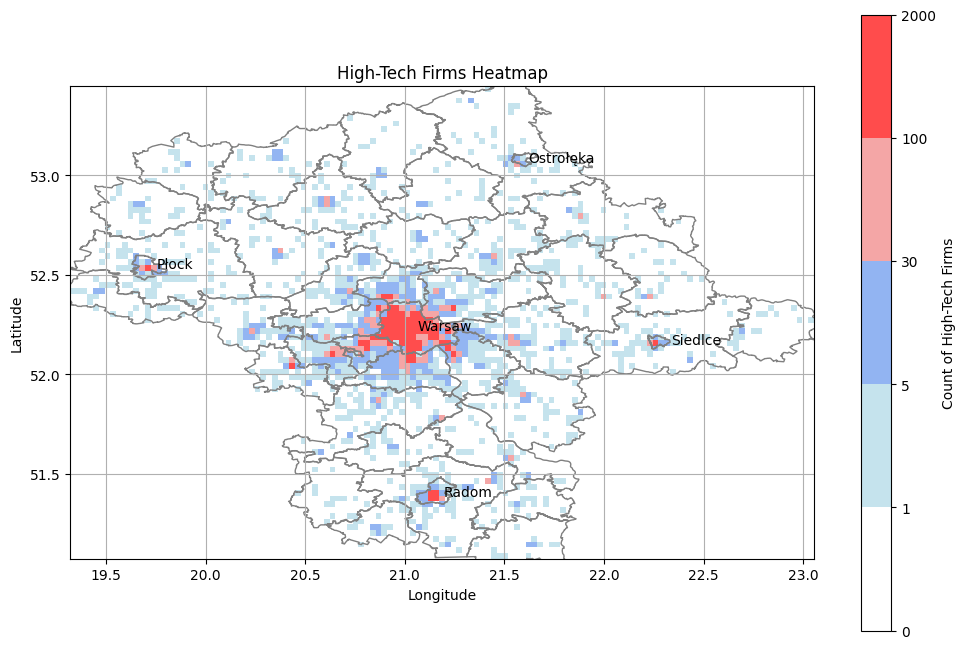

In [16]:
min_lon_maz, max_lon_maz = gdf_ht['lon'].min(), gdf_ht['lon'].max()
min_lat_maz, max_lat_maz = gdf_ht['lat'].min(), gdf_ht['lat'].max()
grid_size = 0.02912

lons_maz = np.arange(min_lon_maz, max_lon_maz, grid_size)
lats_maz = np.arange(min_lat_maz, max_lat_maz, grid_size)

gdf_ht['grid_x_maz_ht'] = np.digitize(gdf_ht['lon'], lons_maz)
gdf_ht['grid_y_maz_ht'] = np.digitize(gdf_ht['lat'], lats_maz)

grid_counts_maz = gdf_ht.groupby(['grid_x_maz_ht', 'grid_y_maz_ht']).size().reset_index(name='firm_count_maz_ht')
gdf_ht = gdf_ht.merge(grid_counts_maz, how='left', on=['grid_x_maz_ht', 'grid_y_maz_ht'])

heatmap_maz = np.zeros((len(lats_maz), len(lons_maz)))

for idx, row in grid_counts_maz.iterrows():
    grid_x, grid_y = row['grid_x_maz_ht'] - 1, row['grid_y_maz_ht'] - 1  
    count = row['firm_count_maz_ht']
    heatmap_maz[grid_y, grid_x] = count


city_lon = [21.017532, 21.14714, 19.70638, 22.29006, 21.5714]
city_lat = [52.237049, 51.40253, 52.54682, 52.16772, 53.0813]
city_names = ['Warsaw', 'Radom', 'Płock', 'Siedlce', 'Ostrołęka']

colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 30, 100, 2000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_maz, cmap=cmap, norm=norm, origin='lower', extent=[min_lon_maz, max_lon_maz, min_lat_maz, max_lat_maz], alpha=0.7)

for city, lon, lat in zip(city_names, city_lon, city_lat):
    plt.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

plt.colorbar(label='Count of High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High-Tech Firms Heatmap')

plt.grid(True)
plt.show()


# FRNN - different groups

In [19]:
import geopandas as gpd
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(gdf['lon'], gdf['lat'])]
gdf = gpd.GeoDataFrame(gdf, geometry=geometry)

radius = 0.00734

company_groups = ['HT', 'HTKIS', 'KIS', 'LT', 'MHT', 'MLT', 'O', 'PMHT']

company_group_counts = {group: [] for group in company_groups}

gdf_sindex = gdf.sindex

for index, location in gdf.iterrows():
    
    buffer_bbox = location['geometry'].buffer(radius).bounds

    candidate_neighbors_idx = list(gdf_sindex.intersection(buffer_bbox))

    potential_neighbors = gdf.iloc[candidate_neighbors_idx]
    neighbors_within_buffer = potential_neighbors[potential_neighbors.geometry.within(location['geometry'].buffer(radius))]

    for group in company_groups:
        num_neighbors = len(neighbors_within_buffer[neighbors_within_buffer['Group'] == group])
        
        company_group_counts[group].append(num_neighbors)

for group, counts in company_group_counts.items():
    gdf[f'{group}_neighbor_count'] = counts

In [21]:
with open('gdf_FRNN.pickle', 'wb') as f:
    pickle.dump(gdf, f)

In [55]:
county_data = pd.read_excel('../data/_countydata.xlsx', header=1)
county_data

,Code,POWIAT,Name,exp_per1,inc_per1,UE_fin,inv_per1,museums,mus_visitors,cinemas_spaces,pop_per_1lib,book_rentals_per1,crime,crime_per1k,apts_bought,unemployment,work_accidents,work_accidents_per1k,students,graduates,avg_salary,avg_salary_to_PL,hipermarkets,supermarkets,depos,stores,all_stores,apts_available,buses,schools,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
0,1400000,0,MAZOWIECKIE,866.61,859.19,1.170926e+08,5256,115,12578.1,119,4846,16.0,142841,26.99,17251,10.7,11.87,5.47,312033,85053,4637.58,123.9,73,608,10,46,737,2112511,15085,3755,314,687,1745,1009
1,1401000,1,Powiat biaĹ‚obrzeski,1006.68,970.87,5.996404e+06,883,0,0.0,0,3376,17.7,748,22.13,0,17.0,0.02,3.49,0,0,3355.88,89.6,0,2,0,0,2,11509,97,28,0,1,19,8
2,1402000,2,Powiat ciechanowski,929.16,937.63,4.047298e+06,4872,3,2921.8,236,4562,23.4,2531,27.72,122,17.3,0.13,5.15,1955,714,3385.81,90.4,0,10,1,1,12,30163,299,89,15,20,32,22
3,1403000,3,Powiat garwoliĹ„ski,929.12,889.09,3.796153e+06,1877,1,129.0,431,3745,16.5,2193,20.21,8,14.5,0.09,3.53,191,89,3277.05,87.5,0,14,0,0,14,33511,351,117,1,11,67,38
4,1404000,4,Powiat gostyniĹ„ski,992.63,1016.06,1.309765e+06,1091,0,0.0,120,3108,17.1,695,14.87,35,23.2,0.07,6.66,0,0,2925.45,78.1,0,7,0,0,7,15798,121,37,0,8,17,12
5,1405000,5,Powiat grodziski,814.44,811.79,6.509519e+05,4385,1,422.0,233,5470,14.6,2055,23.64,0,7.8,0.13,4.30,978,427,3854.84,103.0,0,9,0,0,9,32651,344,56,4,11,26,15
6,1406000,6,Powiat grĂłjecki,896.62,880.54,4.136573e+06,3006,2,153.2,363,4932,15.9,2800,28.42,0,8.6,0.10,4.29,60,20,3589.76,95.9,1,9,0,0,10,35085,337,89,7,16,49,17
7,1407000,7,Powiat kozienicki,1047.61,930.29,3.461797e+06,3985,2,1486.5,0,3278,14.8,1707,27.37,127,19.1,0.08,5.25,0,0,4239.66,113.2,0,5,0,0,5,21415,223,55,4,8,29,14
8,1408000,8,Powiat legionowski,734.25,731.96,2.063938e+06,2995,1,655.7,2198,6464,20.8,2938,26.87,247,14.7,0.09,3.34,0,0,3600.74,96.2,3,11,0,2,16,41107,349,51,2,6,26,17
9,1409000,9,Powiat lipski,1289.51,1215.90,2.599095e+06,411,0,0.0,0,2991,24.5,734,20.32,0,17.0,0.01,2.27,0,0,3098.37,82.7,0,3,0,0,3,13036,58,40,3,6,20,11


In [56]:
# adding county data

gdf = pd.merge(gdf, county_data, on='POWIAT', how='left')

gdf

,?,ID,REGON,POWIAT,GMINA,Address_full,SEK_PKD7,PKD7,GR_LPRAC,lon,lat,tech,if_hightech,empl,sharesEMPL2,ones,locPdens,locAggA,locAggB,locAggC,locAggD,locAggE,locAggF,locAggG,locAggH,locAggI,locAggJ,locAggK,locAggL,locAggM,locAggN,locAggO,locAggP,locAggQ,locAggR,locAggS,locAggT,locAggU,locHH,locBIG,locAggTOTAL,locHightech,locLQ,dist_core_10,dist_core_25,dist_core_50,dist_midsize_10,dist_midsize_25,dist_midsize_50,dist_regional_10,dist_regional_25,dist_regional_50,dist_localbig_10,dist_localbig_25,dist_localbig_50,dist_localsmall_10,dist_localsmall_25,dist_localsmall_50,COREfirms,COREpopul,Group,HT,HTKIS,KIS,LT,MHT,MLT,O,PMHT,geometry,HT_neighbor_count,HTKIS_neighbor_count,KIS_neighbor_count,LT_neighbor_count,MHT_neighbor_count,MLT_neighbor_count,O_neighbor_count,PMHT_neighbor_count,Code,Name,exp_per1,inc_per1,UE_fin,inv_per1,museums,mus_visitors,cinemas_spaces,pop_per_1lib,book_rentals_per1,crime,crime_per1k,apts_bought,unemployment,work_accidents,work_accidents_per1k,students,graduates,avg_salary,avg_salary_to_PL,hipermarkets,supermarkets,depos,stores,all_stores,apts_available,buses,schools,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
0,42342,1,1.406805e+13,17,44,Joachima Lelewela 27 05-480 Karczew,S,9499Z,1,21.23600,52.08347,other,0,5.034085,1.856614e-10,1,26,18,0,38,0,1,25,56,13,1,7,5,1,11,5,0,6,9,1,8,0,0,1.468536e-09,0,205,15,0.851179,0,1,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,O,0,0,0,0,0,0,1,0,POINT (21.23600 52.08347),0,8,11,6,8,18,111,0,1417000,Powiat otwocki,848.16,867.83,3028805.31,3246,1,409.2,674,4356,18.2,2814,23.14,168,9.9,0.18,4.59,2053,403,3490.03,93.2,0,8,1,0,9,44911,493,86,4,20,38,24
1,42343,2,6.721748e+13,7,22,Rogożek 3 26-903 Rogożek,A,0150Z,1,21.36008,51.63636,other,0,5.035107,1.531587e-11,1,1,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.994063e-11,0,3,0,2.586889,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,O,0,0,0,0,0,0,1,0,POINT (21.36008 51.63636),0,0,0,0,0,0,1,0,1407000,Powiat kozienicki,1047.61,930.29,3461797.37,3985,2,1486.5,0,3278,14.8,1707,27.37,127,19.1,0.08,5.25,0,0,4239.66,113.2,0,5,0,0,5,21415,223,55,4,8,29,14
2,118240,3,1.109380e+12,65,58,Ignacego Krasickiego 12A 02-611 Warszawa,G,4690Z,1,21.02140,52.19191,other,0,5.001276,1.518227e-11,1,203,72,4,141,24,12,192,620,111,64,203,98,185,533,121,0,89,101,51,207,0,1,2.685278e-07,34,2829,183,1.126141,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,O,0,0,0,0,0,0,1,0,POINT (21.02140 52.19191),13,359,924,95,25,67,1864,11,1465000,Powiat m. st. Warszawa,0.00,0.00,0.00,10508,61,34800.7,57,6548,14.6,57087,33.36,10604,4.3,6.26,5.29,268555,69272,5077.53,135.6,41,193,4,23,261,872587,4979,859,105,204,311,239
3,210007,4,1.566525e+12,65,188,al. Prymasa Tysiąclecia 62 01-424 Warszawa,G,4643Z,1,20.95726,52.23474,other,0,5.114140,1.587524e-11,1,220,10,1,35,3,4,47,133,25,27,42,19,54,111,29,3,25,24,12,38,0,0,3.089481e-08,6,642,49,1.064512,1,1,1,0,0,0,0,1,1,0,1,1,0,1,1,1,1,O,0,0,0,0,0,0,1,0,POINT (20.95726 52.23474),12,217,516,81,20,93,1656,2,1465000,Powiat m. st. Warszawa,0.00,0.00,0.00,10508,61,34800.7,57,6548,14.6,57087,33.36,10604,4.3,6.26,5.29,268555,69272,5077.53,135.6,41,193,4,23,261,872587,4979,859,105,204,311,239
4,423467,5,1.401995e+13,65,48,Marymoncka 93/97 01-813 Warszawa,S,9511Z,1,20.95403,52.28521,other,0,4.939015,1.787151e-10,1,150,50,0,172,2,2,166,505,110,59,143,66,105,323,104,1,106,111,69,164,0,0,5.495024e-07,16,2258,141,1.584181,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,MLT,0,0,0,0,0,1,0,0,POINT (20.95403 52.28521),3,116,280,69,7,40,941,1,1465000,Powiat m. st. Warszawa,0.00,0.00,0.00,10508,61,34800.7,57,6548,14.6,57087,33.36,10604,4.3,6.26,5.29,268555,69272,5077.53,135.6,41,193,4,23,261,872587,4979,859,105,204,311,239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

# Modelling process

In [296]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [205]:
# gdf['KIS_neighbor_count'] += gdf['O_neighbor_count']
# gdf['MHT_neighbor_count'] += gdf['PMHT_neighbor_count']

In [228]:
# Final predictors

predictors_final = ['locHH', 'empl', 'locPdens','locBIG', 'locAggTOTAL', 'locHightech', 'locLQ', 'dist_core_10', 'dist_core_25', 'dist_core_50', 'dist_midsize_10', 'dist_midsize_25', 'dist_midsize_50', 'dist_regional_10', 'dist_regional_25', 'dist_regional_50', 'dist_localbig_10', 'dist_localbig_25', 'dist_localbig_50', 'dist_localsmall_10', 'dist_localsmall_25', 'dist_localsmall_50', 'exp_per1', 'inc_per1', 'UE_fin', 'museums', 'mus_visitors', 'cinemas_spaces', 'pop_per_1lib', 'book_rentals_per1', 'crime', 'crime_per1k', 'apts_bought', 'unemployment', 'work_accidents', 'work_accidents_per1k', 'students', 'graduates', 'avg_salary', 'avg_salary_to_PL', 'hipermarkets', 'supermarkets', 'depos', 'stores', 'all_stores', 'apts_available', 'buses', 'schools', 'HT_neighbor_count',	'HTKIS_neighbor_count',	'LT_neighbor_count',	'MHT_neighbor_count',	'MLT_neighbor_count',	'O_neighbor_count']

## HT

### Random Forest

In [229]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y = gdf['Group'].apply(lambda x: 1 if x == "HT" else 0)
X = gdf[predictors_final]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    196293
           1       0.52      0.07      0.12       451

    accuracy                           1.00    196744
   macro avg       0.76      0.53      0.56    196744
weighted avg       1.00      1.00      1.00    196744

Accuracy: 0.9977178465416988
Confusion Matrix:
[[196265     28]
 [   421     30]]
Precision: 0.5172413793103449
Recall: 0.06651884700665188
F1-score: 0.11787819253438113


Top 20 Features:
                 Feature  Importance
1                   empl    0.170540
5            locHightech    0.136374
6                  locLQ    0.130806
4            locAggTOTAL    0.078967
53      O_neighbor_count    0.072642
49  HTKIS_neighbor_count    0.059418
52    MLT_neighbor_count    0.054038
50     LT_neighbor_count    0.052894
2               locPdens    0.049362
3                 locBIG    0.044720
51    MHT_neighbor_count    0.041885
0                  locHH    0.036726
48     HT_neighbor_count    0.035626
16      dist_localbig_10    0.004969
19    dist_localsmall_10    0.003448
14      dist_regional_25    0.002883
7           dist_core_10    0.002643
13      dist_regional_10    0.001228
35  work_accidents_per1k    0.000927
28          pop_per_1lib    0.000890


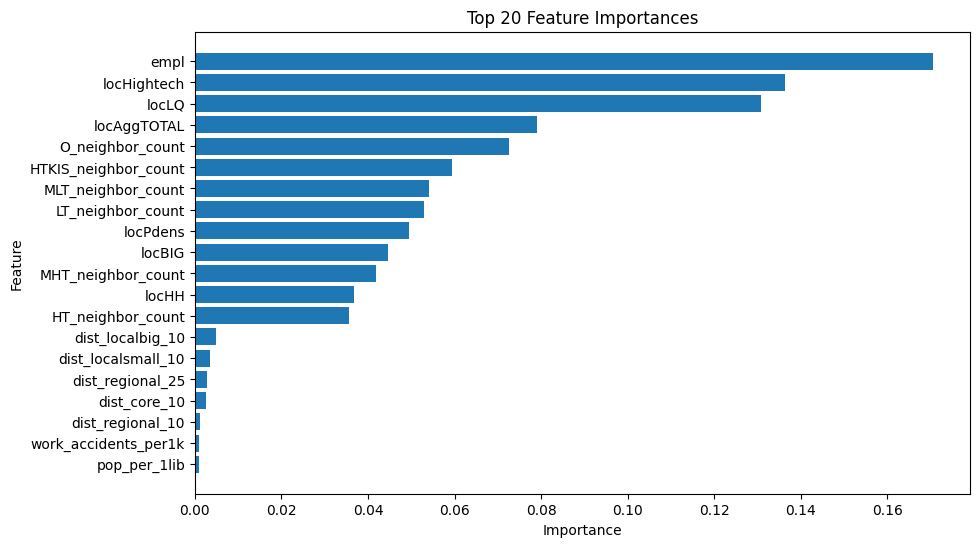

In [230]:
feature_importance = rf_classifier.feature_importances_

ht_rf_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

ht_rf_feature_importance_df = ht_rf_feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Features:")
print(ht_rf_feature_importance_df.head(20))

plt.figure(figsize=(10, 6))
plt.barh(ht_rf_feature_importance_df['Feature'][:20], ht_rf_feature_importance_df['Importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

### XGBoost

In [231]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y = gdf['Group'].apply(lambda x: 1 if x == "HT" else 0)
X = gdf[predictors_final]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_classifier = xgb.XGBClassifier(objective='binary:logistic', random_state=42, scale_pos_weight=450)

xgb_classifier.fit(X_train, y_train)

y_pred = xgb_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    196293
           1       0.03      0.62      0.06       451

    accuracy                           0.96    196744
   macro avg       0.52      0.79      0.52    196744
weighted avg       1.00      0.96      0.98    196744

Accuracy: 0.9560342373846217
Confusion Matrix:
[[187814   8479]
 [   171    280]]
Precision: 0.0319671195341934
Recall: 0.6208425720620843
F1-score: 0.06080347448425624


Top 20 Features:
                 Feature  Importance
48     HT_neighbor_count    0.254089
49  HTKIS_neighbor_count    0.052498
8           dist_core_25    0.046740
6                  locLQ    0.033990
53      O_neighbor_count    0.030121
45        apts_available    0.029313
0                  locHH    0.028474
17      dist_localbig_25    0.025376
26          mus_visitors    0.022400
12       dist_midsize_50    0.022364
52    MLT_neighbor_count    0.022190
5            locHightech    0.020263
19    dist_localsmall_10    0.019855
10       dist_midsize_10    0.018689
28          pop_per_1lib    0.018630
32           apts_bought    0.017972
9           dist_core_50    0.017279
4            locAggTOTAL    0.017089
37             graduates    0.017075
3                 locBIG    0.016668


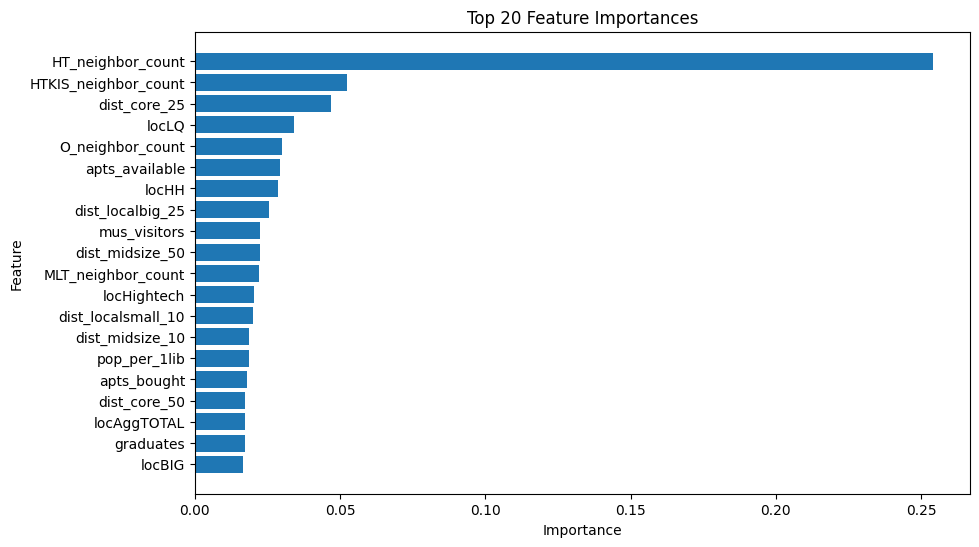

In [232]:
feature_importance = xgb_classifier.feature_importances_

ht_rgb_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

ht_rgb_feature_importance_df = ht_rgb_feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Features:")
print(ht_rgb_feature_importance_df.head(20))

plt.figure(figsize=(10, 6))
plt.barh(ht_rgb_feature_importance_df['Feature'][:20], ht_rgb_feature_importance_df['Importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

### Probit

In [233]:
y = gdf['Group'].apply(lambda x: 1 if x == "HT" else 0)
X = gdf[predictors_final]

X_scaled = scaler.fit_transform(X)

X_scaled = sm.add_constant(X_scaled)

probit_model = sm.Probit(y, X_scaled)

result = probit_model.fit_regularized(method='l1', alpha=1) # could work on the alpha, presuming no significant change

print(result.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.014656914441861443
            Iterations: 688
            Function evaluations: 690
            Gradient evaluations: 688


C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 22 out of 55 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


                          Probit Regression Results                           
Dep. Variable:                  Group   No. Observations:               983719
Model:                         Probit   Df Residuals:                   983664
Method:                           MLE   Df Model:                           54
Date:                Sun, 05 May 2024   Pseudo R-squ.:                 0.06784
Time:                        13:16:27   Log-Likelihood:                -14410.
converged:                       True   LL-Null:                       -15459.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0461      0.012   -247.963      0.000      -3.070      -3.022
x1            -0.7647      0.188     -4.072      0.000      -1.133      -0.397
x2             0.0238      0.003      8.776      0.0

In [235]:
coefficients_flat = result.params[1:].values.flatten()
p_values_flat = result.pvalues[1:].values.flatten()

coefficients = pd.DataFrame({'predictor': predictors_final, 'coefficient': coefficients_flat})
p_values = pd.DataFrame({'predictor': predictors_final, 'p_value': p_values_flat})

ht_result_df = pd.merge(coefficients, p_values, on='predictor')

def get_significance_note(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''

ht_result_df['sig'] = ht_result_df['p_value'].apply(get_significance_note)

ht_result_df['coefficient'] = ht_result_df['coefficient'].round(3).astype(str) + ht_result_df['sig']

ht_result_df.drop(columns=['p_value', 'sig'], inplace=True)

ht_result_df

,predictor,coefficient
0,locHH,-0.765***
1,empl,0.024***
2,locPdens,-0.01
3,locBIG,0.029
4,locAggTOTAL,-0.002
5,locHightech,-0.033
6,locLQ,-0.163***
7,dist_core_10,-0.019
8,dist_core_25,0.139***
9,dist_core_50,0.037


## MHT

### Random Forest

In [236]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y = gdf['Group'].apply(lambda x: 1 if x == "MHT" else 0)
X = gdf[predictors_final]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    195594
           1       0.59      0.08      0.14      1150

    accuracy                           0.99    196744
   macro avg       0.79      0.54      0.57    196744
weighted avg       0.99      0.99      0.99    196744

Accuracy: 0.9943022404749319
Confusion Matrix:
[[195529     65]
 [  1056     94]]
Precision: 0.5911949685534591
Recall: 0.0817391304347826
F1-score: 0.14362108479755537


Top 20 Features:
                 Feature  Importance
1                   empl    0.147147
5            locHightech    0.131813
6                  locLQ    0.127506
4            locAggTOTAL    0.082164
53      O_neighbor_count    0.079517
52    MLT_neighbor_count    0.057650
49  HTKIS_neighbor_count    0.057216
50     LT_neighbor_count    0.053942
2               locPdens    0.052998
51    MHT_neighbor_count    0.047372
3                 locBIG    0.040101
0                  locHH    0.033145
48     HT_neighbor_count    0.027065
16      dist_localbig_10    0.004544
19    dist_localsmall_10    0.003843
14      dist_regional_25    0.002907
7           dist_core_10    0.002258
33          unemployment    0.001928
35  work_accidents_per1k    0.001912
30                 crime    0.001787


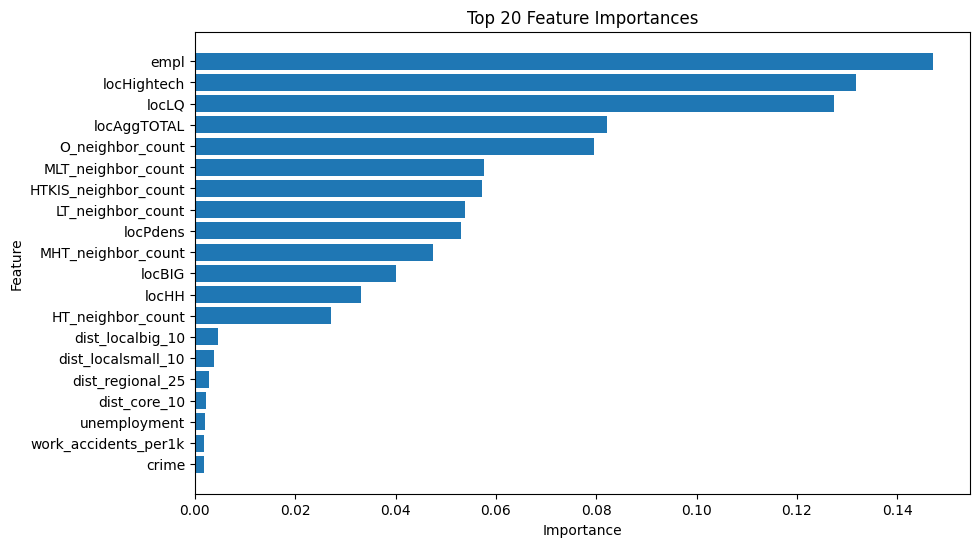

In [237]:
feature_importance = rf_classifier.feature_importances_

mht_rf_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

mht_rf_feature_importance_df = mht_rf_feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Features:")
print(mht_rf_feature_importance_df.head(20))

plt.figure(figsize=(10, 6))
plt.barh(mht_rf_feature_importance_df['Feature'][:20], mht_rf_feature_importance_df['Importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

### XGBoost

In [238]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y = gdf['Group'].apply(lambda x: 1 if x == "MHT" else 0)
X = gdf[predictors_final]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_classifier = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

xgb_classifier.fit(X_train, y_train)

y_pred = xgb_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    195594
           1       0.71      0.04      0.07      1150

    accuracy                           0.99    196744
   macro avg       0.85      0.52      0.54    196744
weighted avg       0.99      0.99      0.99    196744

Accuracy: 0.9942920749806856
Confusion Matrix:
[[195576     18]
 [  1105     45]]
Precision: 0.7142857142857143
Recall: 0.0391304347826087
F1-score: 0.07419620774938171


Top 20 Features:
                 Feature  Importance
51    MHT_neighbor_count    0.104721
0                  locHH    0.041193
49  HTKIS_neighbor_count    0.036299
14      dist_regional_25    0.035015
6                  locLQ    0.034259
53      O_neighbor_count    0.031795
8           dist_core_25    0.031053
26          mus_visitors    0.029096
28          pop_per_1lib    0.028836
45        apts_available    0.027357
50     LT_neighbor_count    0.025615
3                 locBIG    0.025162
46                 buses    0.023541
30                 crime    0.022603
2               locPdens    0.022002
5            locHightech    0.021087
52    MLT_neighbor_count    0.020299
31           crime_per1k    0.019706
43                stores    0.019632
38            avg_salary    0.019615


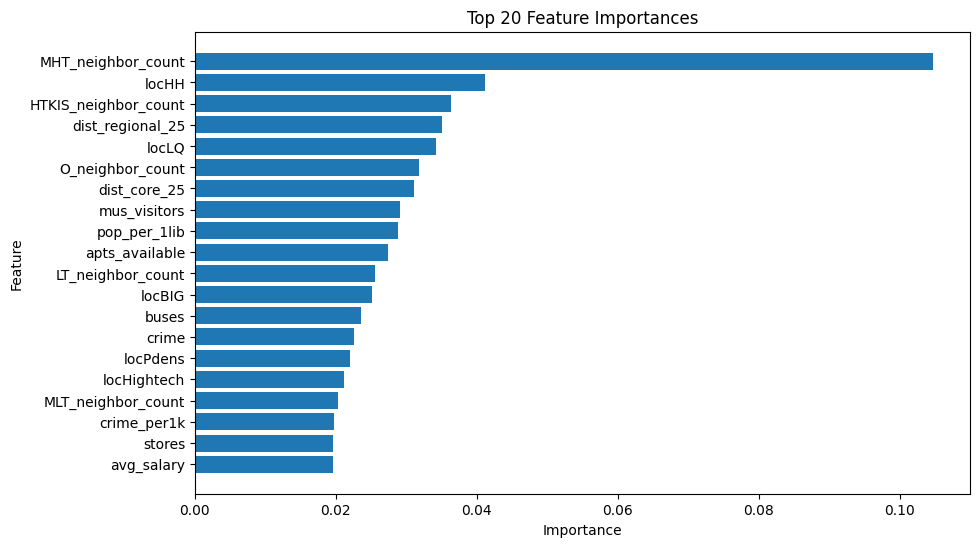

In [239]:
feature_importance = xgb_classifier.feature_importances_

mht_xgb_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

mht_xgb_feature_importance_df = mht_xgb_feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Features:")
print(mht_xgb_feature_importance_df.head(20))

plt.figure(figsize=(10, 6))
plt.barh(mht_xgb_feature_importance_df['Feature'][:20], mht_xgb_feature_importance_df['Importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

### Probit

In [240]:
y = gdf['Group'].apply(lambda x: 1 if x == "MHT" else 0)
X = gdf[predictors_final]

X_scaled = scaler.fit_transform(X)

X_scaled = sm.add_constant(X_scaled)

probit_model = sm.Probit(y, X_scaled)

result = probit_model.fit_regularized(method='l1', alpha=0.7)

print(result.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.03533045227738122
            Iterations: 843
            Function evaluations: 845
            Gradient evaluations: 843


C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 24 out of 55 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


                          Probit Regression Results                           
Dep. Variable:                  Group   No. Observations:               983719
Model:                         Probit   Df Residuals:                   983664
Method:                           MLE   Df Model:                           54
Date:                Sun, 05 May 2024   Pseudo R-squ.:                 0.03143
Time:                        13:25:13   Log-Likelihood:                -34747.
converged:                       True   LL-Null:                       -35875.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.5892      0.006   -454.416      0.000      -2.600      -2.578
x1            -0.7322      0.130     -5.641      0.000      -0.987      -0.478
x2             0.0288      0.002     14.112      0.0

In [241]:
coefficients_flat = result.params[1:].values.flatten()
p_values_flat = result.pvalues[1:].values.flatten()

coefficients = pd.DataFrame({'predictor': predictors_final, 'coefficient': coefficients_flat})
p_values = pd.DataFrame({'predictor': predictors_final, 'p_value': p_values_flat})

mht_result_df = pd.merge(coefficients, p_values, on='predictor')

def get_significance_note(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''

mht_result_df['sig'] = mht_result_df['p_value'].apply(get_significance_note)

mht_result_df['coefficient'] = mht_result_df['coefficient'].round(3).astype(str) + mht_result_df['sig']

mht_result_df.drop(columns=['p_value', 'sig'], inplace=True)

mht_result_df

summary_of_probits = pd.merge(ht_result_df, mht_result_df, on='predictor')

## HTKIS

### Random Forest

In [242]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y = gdf['Group'].apply(lambda x: 1 if x == "HTKIS" else 0)
X = gdf[predictors_final]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98    185381
           1       0.70      0.35      0.47     11363

    accuracy                           0.95    196744
   macro avg       0.83      0.67      0.72    196744
weighted avg       0.95      0.95      0.95    196744

Accuracy: 0.9537774976619363
Confusion Matrix:
[[183691   1690]
 [  7404   3959]]
Precision: 0.7008320056647194
Recall: 0.3484115110446185
F1-score: 0.46543616270867616


Top 20 Features:
                 Feature  Importance
6                  locLQ    0.226720
1                   empl    0.150300
5            locHightech    0.085302
4            locAggTOTAL    0.069219
53      O_neighbor_count    0.063945
49  HTKIS_neighbor_count    0.060179
0                  locHH    0.049953
52    MLT_neighbor_count    0.048751
50     LT_neighbor_count    0.047150
2               locPdens    0.046881
3                 locBIG    0.039028
51    MHT_neighbor_count    0.036002
48     HT_neighbor_count    0.024493
16      dist_localbig_10    0.004231
32           apts_bought    0.003223
19    dist_localsmall_10    0.002942
14      dist_regional_25    0.002440
7           dist_core_10    0.002434
41          supermarkets    0.002429
36              students    0.002121


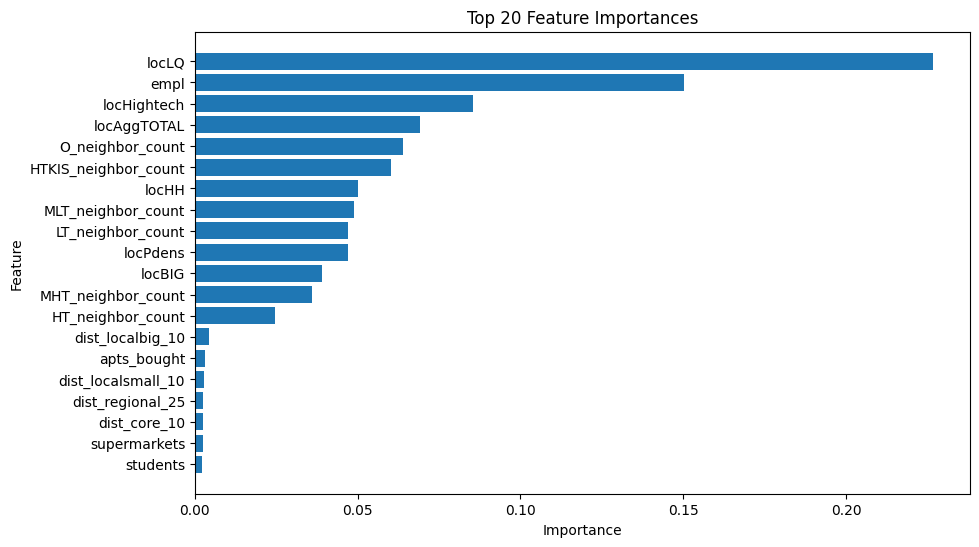

In [243]:
feature_importance = rf_classifier.feature_importances_

htkis_rf_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

htkis_rf_feature_importance_df = htkis_rf_feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Features:")
print(htkis_rf_feature_importance_df.head(20))

plt.figure(figsize=(10, 6))
plt.barh(htkis_rf_feature_importance_df['Feature'][:20], htkis_rf_feature_importance_df['Importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

### XGBoost

In [244]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y = gdf['Group'].apply(lambda x: 1 if x == "HTKIS" else 0)
X = gdf[predictors_final]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_classifier = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

xgb_classifier.fit(X_train, y_train)

y_pred = xgb_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    185381
           1       0.81      0.25      0.38     11363

    accuracy                           0.95    196744
   macro avg       0.88      0.62      0.68    196744
weighted avg       0.95      0.95      0.94    196744

Accuracy: 0.953243809214004
Confusion Matrix:
[[184705    676]
 [  8523   2840]]
Precision: 0.8077360637087599
Recall: 0.249933996303793
F1-score: 0.3817460850863633


Top 20 Features:
                 Feature  Importance
32           apts_bought    0.276251
37             graduates    0.118183
49  HTKIS_neighbor_count    0.062757
7           dist_core_10    0.039815
16      dist_localbig_10    0.037963
33          unemployment    0.036963
25               museums    0.030589
43                stores    0.029469
9           dist_core_50    0.029283
6                  locLQ    0.027217
14      dist_regional_25    0.020947
44            all_stores    0.019022
8           dist_core_25    0.018566
28          pop_per_1lib    0.017377
0                  locHH    0.015942
5            locHightech    0.013885
45        apts_available    0.013071
3                 locBIG    0.011035
46                 buses    0.010189
53      O_neighbor_count    0.009565


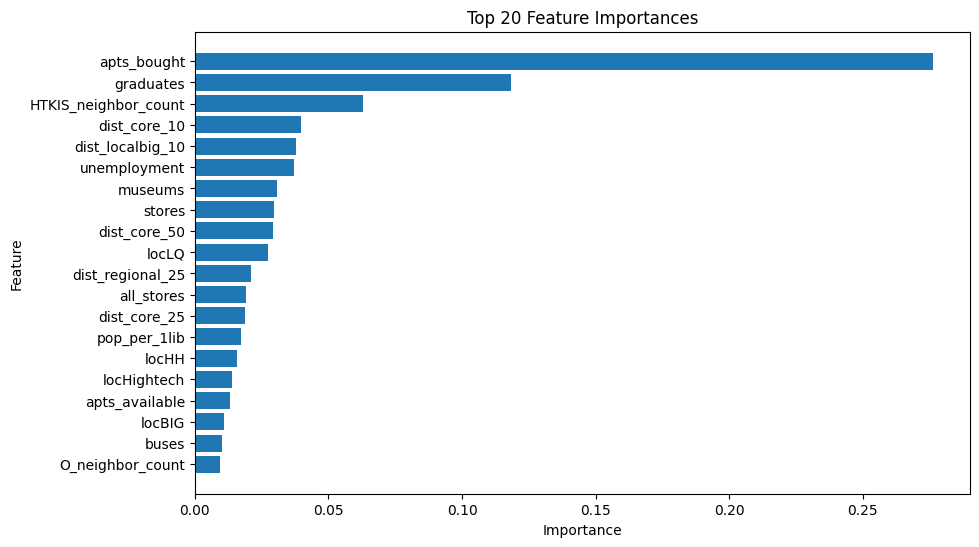

In [245]:
feature_importance = xgb_classifier.feature_importances_

htkis_xgb_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

htkis_xgb_feature_importance_df = htkis_xgb_feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Features:")
print(htkis_xgb_feature_importance_df.head(20))

plt.figure(figsize=(10, 6))
plt.barh(htkis_xgb_feature_importance_df['Feature'][:20], htkis_xgb_feature_importance_df['Importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

### Probit

In [246]:
y = gdf['Group'].apply(lambda x: 1 if x == "HTKIS" else 0)
X = gdf[predictors_final]

X_scaled = scaler.fit_transform(X)

X_scaled = sm.add_constant(X_scaled)

probit_model = sm.Probit(y, X_scaled)

result = probit_model.fit_regularized(method='l1', alpha=0.7)

print(result.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.20513458138870258
            Iterations: 809
            Function evaluations: 810
            Gradient evaluations: 809


C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 20 out of 55 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


                          Probit Regression Results                           
Dep. Variable:                  Group   No. Observations:               983719
Model:                         Probit   Df Residuals:                   983664
Method:                           MLE   Df Model:                           54
Date:                Sun, 05 May 2024   Pseudo R-squ.:                 0.07027
Time:                        13:33:59   Log-Likelihood:            -2.0179e+05
converged:                       True   LL-Null:                   -2.1704e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6984      0.003   -670.762      0.000      -1.703      -1.693
x1            -0.2110      0.026     -8.172      0.000      -0.262      -0.160
x2            -0.0103      0.002     -4.592      0.0

In [247]:
coefficients_flat = result.params[1:].values.flatten()
p_values_flat = result.pvalues[1:].values.flatten()

coefficients = pd.DataFrame({'predictor': predictors_final, 'coefficient': coefficients_flat})
p_values = pd.DataFrame({'predictor': predictors_final, 'p_value': p_values_flat})

htkis_result_df = pd.merge(coefficients, p_values, on='predictor')

def get_significance_note(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''

htkis_result_df['sig'] = htkis_result_df['p_value'].apply(get_significance_note)

htkis_result_df['coefficient'] = htkis_result_df['coefficient'].round(3).astype(str) + htkis_result_df['sig']

htkis_result_df.drop(columns=['p_value', 'sig'], inplace=True)

htkis_result_df

summary_of_probits = pd.merge(summary_of_probits, htkis_result_df, on='predictor')

## MLT

### Random Forest

In [248]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y = gdf['Group'].apply(lambda x: 1 if x == "MLT" else 0)
X = gdf[predictors_final]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    189215
           1       0.51      0.13      0.20      7529

    accuracy                           0.96    196744
   macro avg       0.74      0.56      0.59    196744
weighted avg       0.95      0.96      0.95    196744

Accuracy: 0.9618387345992763
Confusion Matrix:
[[188269    946]
 [  6562    967]]
Precision: 0.505488761108207
Recall: 0.12843671138265375
F1-score: 0.20482948527854267


Top 20 Features:
                 Feature  Importance
1                   empl    0.195262
6                  locLQ    0.156965
53      O_neighbor_count    0.092870
4            locAggTOTAL    0.091090
52    MLT_neighbor_count    0.070353
5            locHightech    0.057552
2               locPdens    0.053853
49  HTKIS_neighbor_count    0.052443
50     LT_neighbor_count    0.051699
3                 locBIG    0.033497
51    MHT_neighbor_count    0.032272
0                  locHH    0.026019
48     HT_neighbor_count    0.018905
19    dist_localsmall_10    0.004292
16      dist_localbig_10    0.003837
14      dist_regional_25    0.002816
20    dist_localsmall_25    0.002338
13      dist_regional_10    0.002045
45        apts_available    0.001966
46                 buses    0.001958


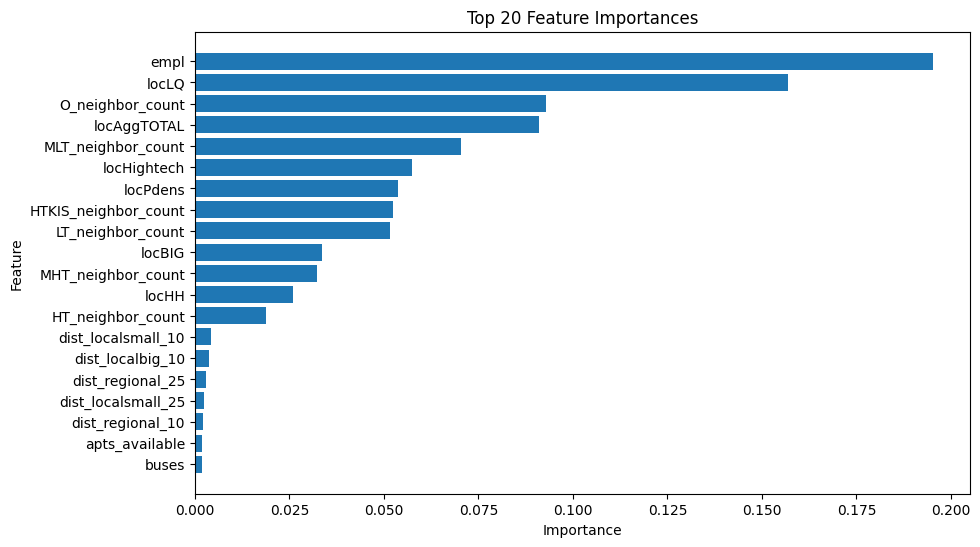

In [249]:
feature_importance = rf_classifier.feature_importances_

mlt_rf_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

mlt_rf_feature_importance_df = mlt_rf_feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Features:")
print(mlt_rf_feature_importance_df.head(20))

plt.figure(figsize=(10, 6))
plt.barh(mlt_rf_feature_importance_df['Feature'][:20], mlt_rf_feature_importance_df['Importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

### XGBoost

In [250]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y = gdf['Group'].apply(lambda x: 1 if x == "MLT" else 0)
X = gdf[predictors_final]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_classifier = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

xgb_classifier.fit(X_train, y_train)

y_pred = xgb_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    189215
           1       0.64      0.06      0.12      7529

    accuracy                           0.96    196744
   macro avg       0.80      0.53      0.55    196744
weighted avg       0.95      0.96      0.95    196744

Accuracy: 0.9627942910584313
Confusion Matrix:
[[188946    269]
 [  7051    478]]
Precision: 0.6398929049531459
Recall: 0.06348784699163236
F1-score: 0.11551474142097633


Top 20 Features:
                 Feature  Importance
52    MLT_neighbor_count    0.126823
53      O_neighbor_count    0.051076
45        apts_available    0.046125
49  HTKIS_neighbor_count    0.045947
6                  locLQ    0.044780
0                  locHH    0.038546
32           apts_bought    0.029881
42                 depos    0.028045
11       dist_midsize_25    0.027709
8           dist_core_25    0.026783
50     LT_neighbor_count    0.025553
20    dist_localsmall_25    0.023976
2               locPdens    0.023853
28          pop_per_1lib    0.022631
4            locAggTOTAL    0.021560
5            locHightech    0.021108
38            avg_salary    0.020171
3                 locBIG    0.018545
31           crime_per1k    0.017805
16      dist_localbig_10    0.016699


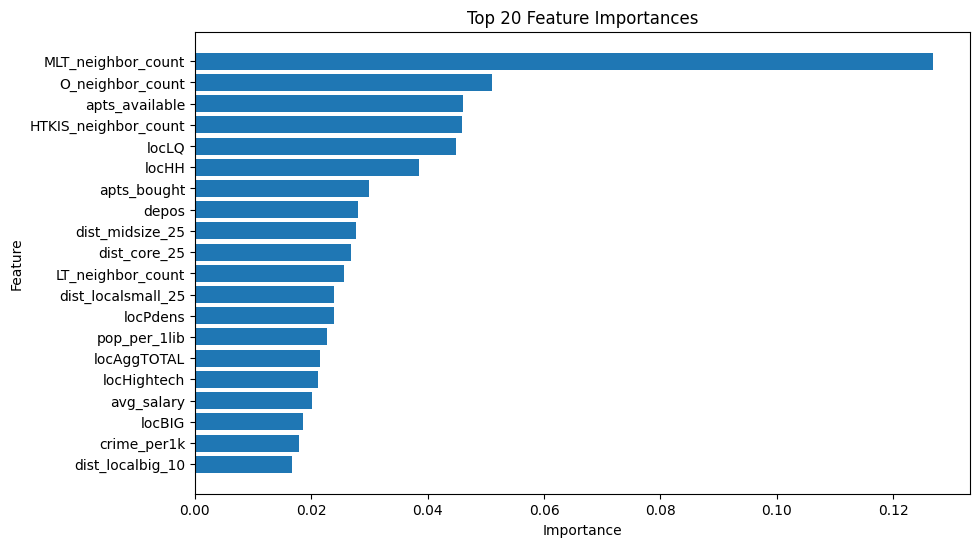

In [251]:
feature_importance = xgb_classifier.feature_importances_

mlt_xgb_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

mlt_xgb_feature_importance_df = mlt_xgb_feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Features:")
print(mlt_xgb_feature_importance_df.head(20))

plt.figure(figsize=(10, 6))
plt.barh(mlt_xgb_feature_importance_df['Feature'][:20], mlt_xgb_feature_importance_df['Importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

### Probit

In [252]:
y = gdf['Group'].apply(lambda x: 1 if x == "MLT" else 0)
X = gdf[predictors_final]

X_scaled = scaler.fit_transform(X)

X_scaled = sm.add_constant(X_scaled)

probit_model = sm.Probit(y, X_scaled)

result = probit_model.fit_regularized(method='l1', alpha=0.7)

print(result.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.15284954013719088
            Iterations: 852
            Function evaluations: 854
            Gradient evaluations: 852


C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 22 out of 55 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


                          Probit Regression Results                           
Dep. Variable:                  Group   No. Observations:               983719
Model:                         Probit   Df Residuals:                   983664
Method:                           MLE   Df Model:                           54
Date:                Sun, 05 May 2024   Pseudo R-squ.:                 0.04686
Time:                        13:44:52   Log-Likelihood:            -1.5035e+05
converged:                       True   LL-Null:                   -1.5775e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8674      0.003   -651.591      0.000      -1.873      -1.862
x1            -0.6041      0.075     -8.090      0.000      -0.751      -0.458
x2             0.0122      0.002      6.135      0.0

In [254]:
coefficients_flat = result.params[1:].values.flatten()
p_values_flat = result.pvalues[1:].values.flatten()

coefficients = pd.DataFrame({'predictor': predictors_final, 'coefficient': coefficients_flat})
p_values = pd.DataFrame({'predictor': predictors_final, 'p_value': p_values_flat})

mlt_result_df = pd.merge(coefficients, p_values, on='predictor')

def get_significance_note(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''

mlt_result_df['sig'] = mlt_result_df['p_value'].apply(get_significance_note)

mlt_result_df['coefficient'] = mlt_result_df['coefficient'].round(3).astype(str) + mlt_result_df['sig']

mlt_result_df.drop(columns=['p_value', 'sig'], inplace=True)

mlt_result_df

summary_of_probits = pd.merge(summary_of_probits, mlt_result_df, on='predictor', suffixes = ('_htkis','_mlt'))

## LT

### Random Forest

In [256]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y = gdf['Group'].apply(lambda x: 1 if x == "LT" else 0)
X = gdf[predictors_final]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    190620
           1       0.66      0.21      0.32      6124

    accuracy                           0.97    196744
   macro avg       0.82      0.60      0.65    196744
weighted avg       0.97      0.97      0.96    196744

Accuracy: 0.9720601390639613
Confusion Matrix:
[[189964    656]
 [  4841   1283]]
Precision: 0.6616812790097989
Recall: 0.20950359242325278
F1-score: 0.31824382984000993


Top 20 Features:
                 Feature  Importance
6                  locLQ    0.179335
1                   empl    0.150734
53      O_neighbor_count    0.085305
4            locAggTOTAL    0.085166
50     LT_neighbor_count    0.066570
5            locHightech    0.060693
52    MLT_neighbor_count    0.056254
2               locPdens    0.054924
49  HTKIS_neighbor_count    0.053894
0                  locHH    0.047184
3                 locBIG    0.037124
51    MHT_neighbor_count    0.034595
48     HT_neighbor_count    0.022602
19    dist_localsmall_10    0.004178
16      dist_localbig_10    0.004178
14      dist_regional_25    0.003155
46                 buses    0.002293
7           dist_core_10    0.002241
20    dist_localsmall_25    0.002012
39      avg_salary_to_PL    0.001899


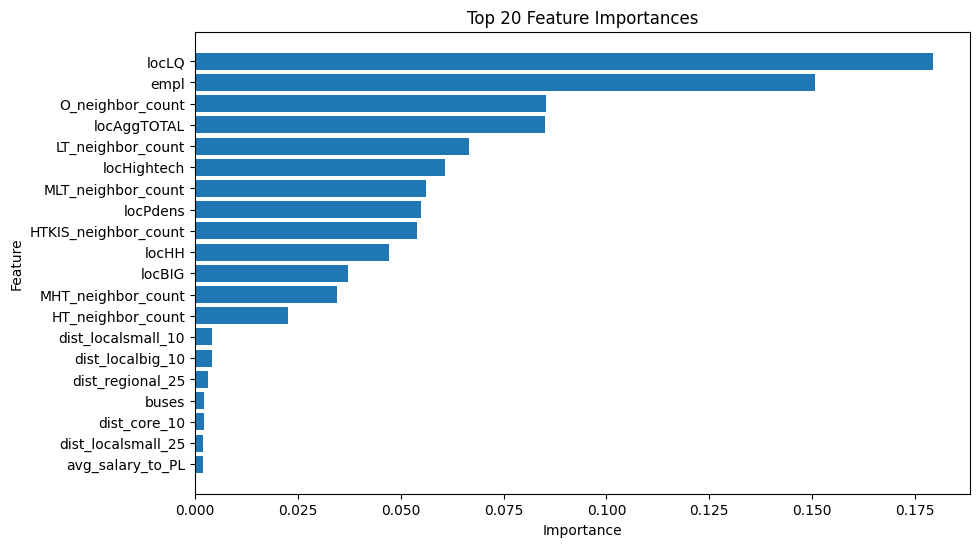

In [257]:
# Get feature importances
feature_importance = rf_classifier.feature_importances_

# Create a DataFrame to store feature importances
lt_rf_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

# Sort the DataFrame by importance
lt_rf_feature_importance_df = lt_rf_feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the top features
print("Top 20 Features:")
print(lt_rf_feature_importance_df.head(20))

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(lt_rf_feature_importance_df['Feature'][:20], lt_rf_feature_importance_df['Importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.show()

### XGBoost

In [258]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y = gdf['Group'].apply(lambda x: 1 if x == "LT" else 0)
X = gdf[predictors_final]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_classifier = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

xgb_classifier.fit(X_train, y_train)

y_pred = xgb_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    190620
           1       0.63      0.22      0.33      6124

    accuracy                           0.97    196744
   macro avg       0.80      0.61      0.66    196744
weighted avg       0.96      0.97      0.97    196744

Accuracy: 0.9716992640182166
Confusion Matrix:
[[189808    812]
 [  4756   1368]]
Precision: 0.6275229357798165
Recall: 0.22338340953625083
F1-score: 0.3294797687861272


Top 20 Features:
                 Feature  Importance
50     LT_neighbor_count    0.085620
49  HTKIS_neighbor_count    0.057246
0                  locHH    0.053228
16      dist_localbig_10    0.049899
45        apts_available    0.043296
6                  locLQ    0.041423
8           dist_core_25    0.037700
38            avg_salary    0.031914
2               locPdens    0.030663
53      O_neighbor_count    0.027861
25               museums    0.027444
3                 locBIG    0.026611
32           apts_bought    0.025712
52    MLT_neighbor_count    0.025273
12       dist_midsize_50    0.025127
4            locAggTOTAL    0.022919
14      dist_regional_25    0.021124
18      dist_localbig_50    0.020023
28          pop_per_1lib    0.019527
35  work_accidents_per1k    0.019032


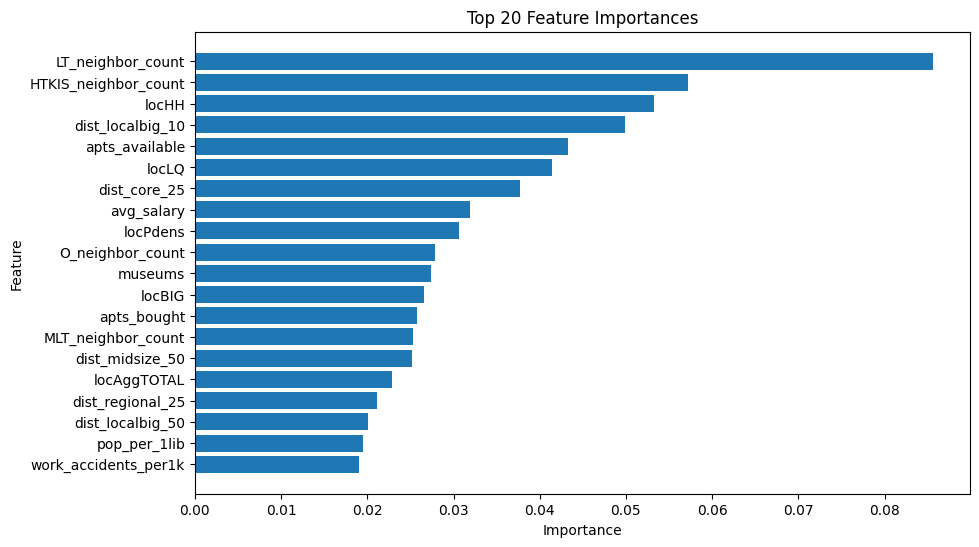

In [259]:
# Get feature importances from a pre-trained XGBoost model (xgb_classifier)
feature_importance = xgb_classifier.feature_importances_

# Create a DataFrame to store feature importances
lt_xgb_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

# Sort the DataFrame by importance
lt_xgb_feature_importance_df = lt_xgb_feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the top features
print("Top 20 Features:")
print(lt_xgb_feature_importance_df.head(20))

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(lt_xgb_feature_importance_df['Feature'][:20], lt_xgb_feature_importance_df['Importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.show()

### Probit

In [276]:
y = gdf['Group'].apply(lambda x: 1 if x == "LT" else 0)
X = gdf[predictors_final]

X_scaled = scaler.fit_transform(X)

X_scaled = sm.add_constant(X_scaled)

probit_model = sm.Probit(y, X_scaled)

result = probit_model.fit_regularized(method='l1', alpha=0.7)

print(result.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.13235619247092492
            Iterations: 839
            Function evaluations: 842
            Gradient evaluations: 839


C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 55 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


                          Probit Regression Results                           
Dep. Variable:                  Group   No. Observations:               983719
Model:                         Probit   Df Residuals:                   983664
Method:                           MLE   Df Model:                           54
Date:                Sun, 05 May 2024   Pseudo R-squ.:                 0.03495
Time:                        14:18:13   Log-Likelihood:            -1.3019e+05
converged:                       True   LL-Null:                   -1.3491e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9436      0.003   -646.030      0.000      -1.949      -1.938
x1            -0.7630      0.076     -9.985      0.000      -0.913      -0.613
x2             0.0288      0.002     17.860      0.0

In [277]:
coefficients_flat = result.params[1:].values.flatten()
p_values_flat = result.pvalues[1:].values.flatten()

coefficients = pd.DataFrame({'predictor': predictors_final, 'coefficient': coefficients_flat})
p_values = pd.DataFrame({'predictor': predictors_final, 'p_value': p_values_flat})

lt_result_df = pd.merge(coefficients, p_values, on='predictor')

def get_significance_note(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''

lt_result_df['sig'] = lt_result_df['p_value'].apply(get_significance_note)

lt_result_df['coefficient'] = lt_result_df['coefficient'].round(3).astype(str) + lt_result_df['sig']

lt_result_df.drop(columns=['p_value', 'sig'], inplace=True)

lt_result_df

summary_of_probits = pd.merge(summary_of_probits, lt_result_df, on='predictor', suffixes = ('_mlt','_lt'))

## O

### Random Forest

In [262]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y = gdf['Group'].apply(lambda x: 1 if x == "O" else 0)
X = gdf[predictors_final]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.69      0.76     53495
           1       0.89      0.96      0.92    143249

    accuracy                           0.88    196744
   macro avg       0.88      0.82      0.84    196744
weighted avg       0.88      0.88      0.88    196744

Accuracy: 0.8847182124994917
Confusion Matrix:
[[ 36733  16762]
 [  5919 137330]]
Precision: 0.8912208291150742
Recall: 0.9586803398278522
F1-score: 0.923720576711587


Top 20 Features:
                 Feature  Importance
6                  locLQ    0.290241
1                   empl    0.092562
4            locAggTOTAL    0.062688
53      O_neighbor_count    0.060875
0                  locHH    0.057672
49  HTKIS_neighbor_count    0.054408
52    MLT_neighbor_count    0.051713
5            locHightech    0.051516
50     LT_neighbor_count    0.050566
2               locPdens    0.047295
51    MHT_neighbor_count    0.036019
3                 locBIG    0.031302
48     HT_neighbor_count    0.021948
8           dist_core_25    0.008600
33          unemployment    0.007956
28          pop_per_1lib    0.006328
32           apts_bought    0.005926
41          supermarkets    0.004160
19    dist_localsmall_10    0.003958
34        work_accidents    0.003902


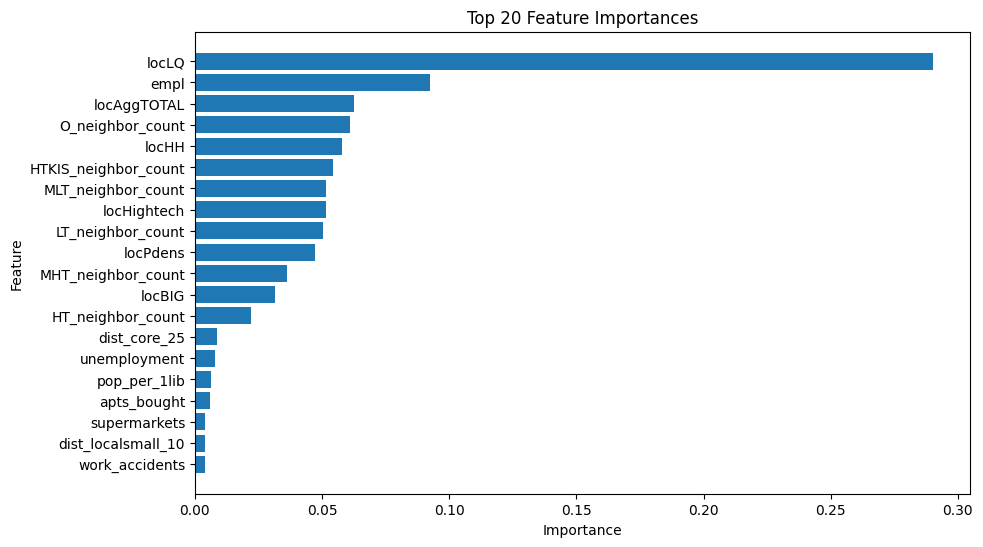

In [263]:
# Get feature importances
feature_importance = rf_classifier.feature_importances_

# Create a DataFrame to store feature importances
o_rf_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

# Sort the DataFrame by importance
o_rf_feature_importance_df = o_rf_feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the top features
print("Top 20 Features:")
print(o_rf_feature_importance_df.head(20))

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(o_rf_feature_importance_df['Feature'][:20], o_rf_feature_importance_df['Importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.show()

### XGBoost

In [264]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y = gdf['Group'].apply(lambda x: 1 if x == "O" else 0)
X = gdf[predictors_final]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_classifier = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

xgb_classifier.fit(X_train, y_train)

y_pred = xgb_classifier.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.65      0.74     53495
           1       0.88      0.96      0.92    143249

    accuracy                           0.87    196744
   macro avg       0.87      0.80      0.83    196744
weighted avg       0.87      0.87      0.87    196744

Accuracy: 0.8743036636441264
Confusion Matrix:
[[ 34741  18754]
 [  5976 137273]]
Precision: 0.8798028546341339
Recall: 0.9582824312909689
F1-score: 0.9173672462877078


Top 20 Features:
                 Feature  Importance
8           dist_core_25    0.285165
49  HTKIS_neighbor_count    0.098968
33          unemployment    0.070816
42                 depos    0.057262
32           apts_bought    0.035270
6                  locLQ    0.032747
45        apts_available    0.026634
52    MLT_neighbor_count    0.025926
7           dist_core_10    0.019878
0                  locHH    0.018877
16      dist_localbig_10    0.018341
14      dist_regional_25    0.018272
35  work_accidents_per1k    0.016672
18      dist_localbig_50    0.015972
3                 locBIG    0.014900
25               museums    0.014612
5            locHightech    0.012233
4            locAggTOTAL    0.011333
19    dist_localsmall_10    0.011124
53      O_neighbor_count    0.010807


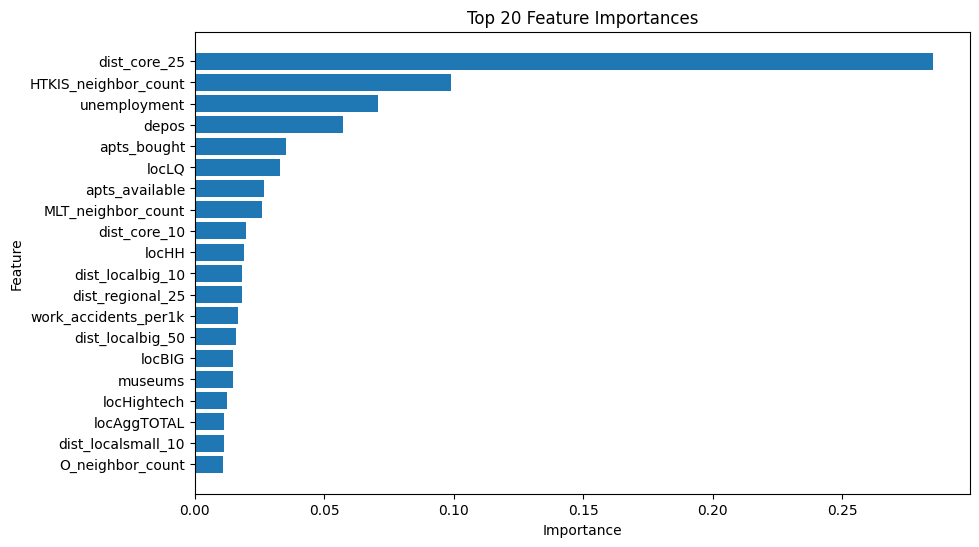

In [265]:
# Get feature importances from a pre-trained XGBoost model (xgb_classifier)
feature_importance = xgb_classifier.feature_importances_

# Create a DataFrame to store feature importances
o_xgb_feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

# Sort the DataFrame by importance
o_xgb_feature_importance_df = o_xgb_feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the top features
print("Top 20 Features:")
print(o_xgb_feature_importance_df.head(20))

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(o_xgb_feature_importance_df['Feature'][:20], o_xgb_feature_importance_df['Importance'][:20])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.show()

### Probit

In [278]:
y = gdf['Group'].apply(lambda x: 1 if x == "O" else 0)
X = gdf[predictors_final]

X_scaled = scaler.fit_transform(X)

X_scaled = sm.add_constant(X_scaled)

probit_model = sm.Probit(y, X_scaled)

result = probit_model.fit_regularized(method='l1', alpha=0.7)

print(result.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.5319503517069698
            Iterations: 876
            Function evaluations: 878
            Gradient evaluations: 876


C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 27 out of 55 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


                          Probit Regression Results                           
Dep. Variable:                  Group   No. Observations:               983719
Model:                         Probit   Df Residuals:                   983664
Method:                           MLE   Df Model:                           54
Date:                Sun, 05 May 2024   Pseudo R-squ.:                 0.08701
Time:                        14:21:03   Log-Likelihood:            -5.2328e+05
converged:                       True   LL-Null:                   -5.7315e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6862      0.001    466.017      0.000       0.683       0.689
x1            -0.0045      0.001     -4.058      0.000      -0.007      -0.002
x2         -7.593e-05      0.001     -0.059      0.9

In [279]:
coefficients_flat = result.params[1:].values.flatten()
p_values_flat = result.pvalues[1:].values.flatten()

coefficients = pd.DataFrame({'predictor': predictors_final, 'coefficient': coefficients_flat})
p_values = pd.DataFrame({'predictor': predictors_final, 'p_value': p_values_flat})

o_result_df = pd.merge(coefficients, p_values, on='predictor')

def get_significance_note(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''

o_result_df['sig'] = o_result_df['p_value'].apply(get_significance_note)

o_result_df['coefficient'] = o_result_df['coefficient'].round(3).astype(str) + o_result_df['sig']

o_result_df.drop(columns=['p_value', 'sig'], inplace=True)

o_result_df

summary_of_probits = pd.merge(summary_of_probits, o_result_df, on='predictor', suffixes = ('_lt','_o'))

# Summary

In [280]:
summary_of_probits.columns = ['predictor', 'HT', 'MHT', 'HTKIS', 'MLT', 'LT', 'O']
summary_of_probits

,predictor,HT,MHT,HTKIS,MLT,LT,O
0,locHH,-0.765***,-0.732***,-0.211***,-0.604***,-0.763***,-0.005***
1,empl,0.024***,0.029***,-0.01***,0.012***,0.029***,-0.0
2,locPdens,-0.01,-0.01,0.068***,-0.119***,-0.024**,-0.077***
3,locBIG,0.029,0.046***,0.033***,0.038***,0.003,-0.093***
4,locAggTOTAL,-0.002,-0.109***,-0.018,-0.029,-0.067***,0.094***
5,locHightech,-0.033,0.074**,-0.007,-0.02,0.077***,-0.009
6,locLQ,-0.163***,-0.115***,0.055***,-0.214***,-0.203***,0.016***
7,dist_core_10,-0.019,-0.021*,0.002,-0.017***,0.001,-0.003
8,dist_core_25,0.139***,0.071***,0.108***,0.049***,0.062***,-0.15***
9,dist_core_50,0.037,0.016,0.03***,0.038***,0.019*,-0.041***


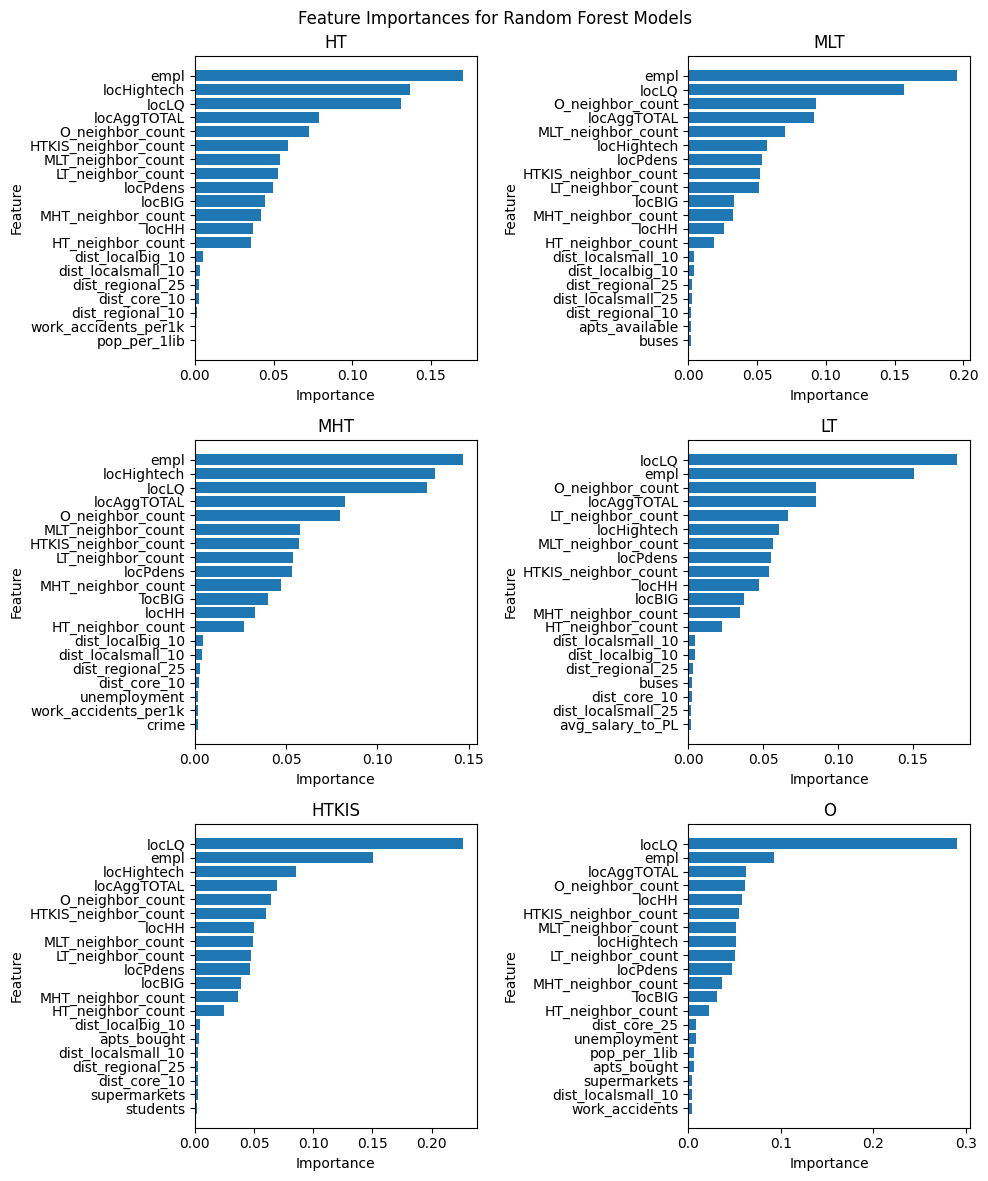

In [292]:
dfs_rf = [ht_rf_feature_importance_df, mht_rf_feature_importance_df, htkis_rf_feature_importance_df, mlt_rf_feature_importance_df, lt_rf_feature_importance_df, o_rf_feature_importance_df]

model_names = ['HT', 'MHT', 'HTKIS', 'MLT', 'LT', 'O']

fig, axs = plt.subplots(3, 2, figsize=(10, 12))
fig.suptitle('Feature Importances for Random Forest Models')

for i, df in enumerate(dfs_rf):
    row = i % 3
    col = i // 3
    axs[row, col].barh(df['Feature'][:20], df['Importance'][:20])
    axs[row, col].set_xlabel('Importance')
    axs[row, col].set_ylabel('Feature')
    axs[row, col].set_title(f'{model_names[i]}')
    axs[row, col].invert_yaxis()

plt.tight_layout()
plt.show()

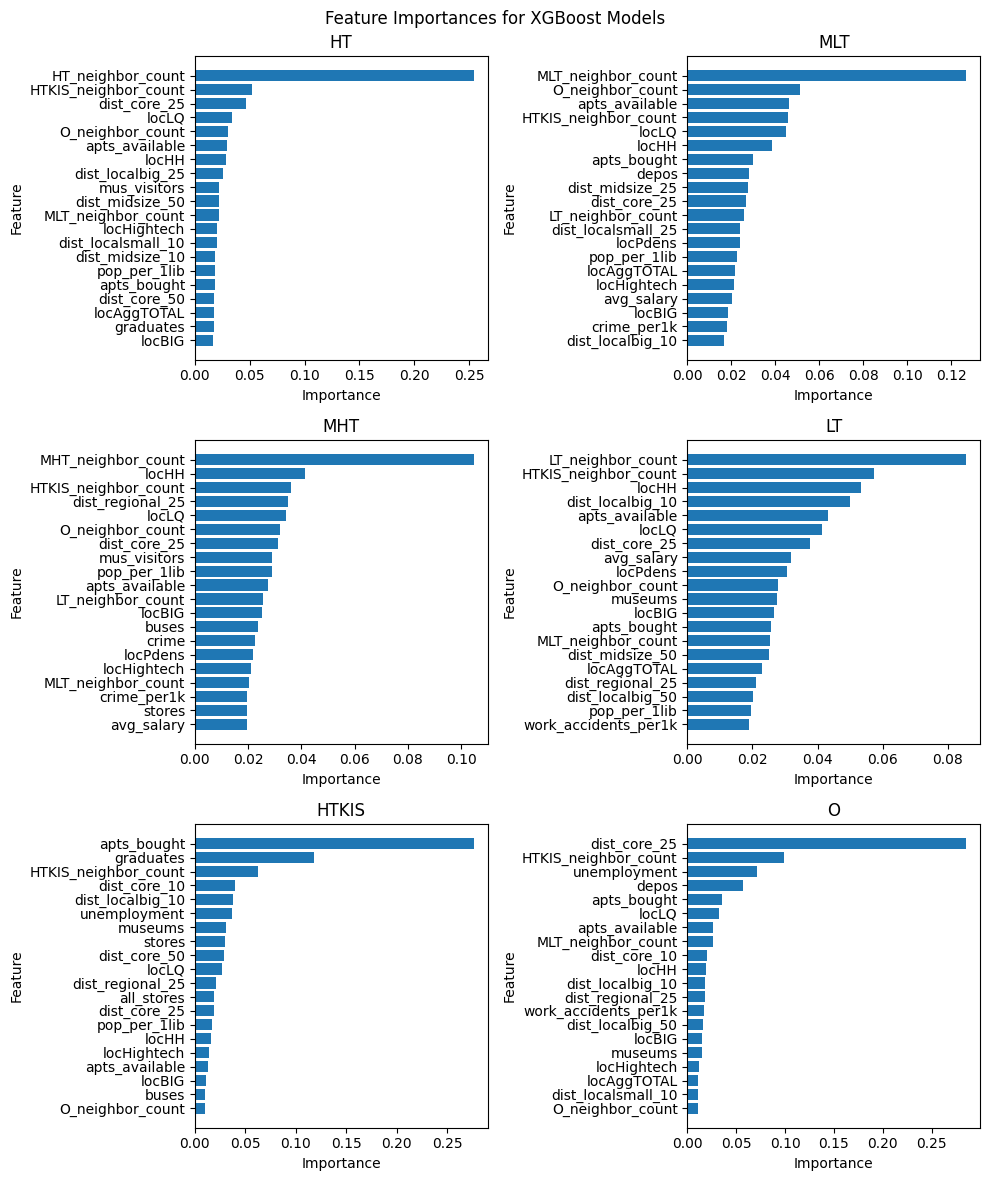

In [294]:
dfs_xgb = [ht_rgb_feature_importance_df, mht_xgb_feature_importance_df, htkis_xgb_feature_importance_df, mlt_xgb_feature_importance_df, lt_xgb_feature_importance_df, o_xgb_feature_importance_df]

model_names = ['HT', 'MHT', 'HTKIS', 'MLT', 'LT', 'O']

fig, axs = plt.subplots(3, 2, figsize=(10, 12))
fig.suptitle('Feature Importances for XGBoost Models')

for i, df in enumerate(dfs_xgb):
    row = i % 3
    col = i // 3
    axs[row, col].barh(df['Feature'][:20], df['Importance'][:20])
    axs[row, col].set_xlabel('Importance')
    axs[row, col].set_ylabel('Feature')
    axs[row, col].set_title(f'{model_names[i]}')
    axs[row, col].invert_yaxis()

plt.tight_layout()
plt.show()